# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [3]:
df.count()

Trip ID              144015
Duration             144015
Start Date           144015
Start Station        144015
Start Terminal       144015
End Date             144015
End Station          144015
End Terminal         144015
Bike #               144015
Subscription Type    144015
Zip Code             137885
dtype: int64

Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [4]:
df.columns

Index(['Trip ID', 'Duration', 'Start Date', 'Start Station', 'Start Terminal',
       'End Date', 'End Station', 'End Terminal', 'Bike #',
       'Subscription Type', 'Zip Code'],
      dtype='object')

In [5]:
df.columns = [col.replace(' ', '_').replace('#', 'num') for col in df.columns]

In [6]:
df.columns

Index(['Trip_ID', 'Duration', 'Start_Date', 'Start_Station', 'Start_Terminal',
       'End_Date', 'End_Station', 'End_Terminal', 'Bike_num',
       'Subscription_Type', 'Zip_Code'],
      dtype='object')

How many types of subscription options are there? What are the different subscription types?

In [7]:
df.groupby(by='Subscription_Type').agg('count')

,Trip_ID,Duration,Start_Date,Start_Station,Start_Terminal,End_Date,End_Station,End_Terminal,Bike_num,Zip_Code
Subscription_Type,,,,,,,,,,
Customer,30368,30368,30368,30368,30368,30368,30368,30368,30368,24238
Subscriber,113647,113647,113647,113647,113647,113647,113647,113647,113647,113647


In [22]:
df2 = df.groupby(by='Subscription_Type').agg('count')['Trip_ID']

What is the frequency of each subscription option?

Please plot the frequency of each subscription option with a pie chart:

In [23]:
import seaborn as sns

([<matplotlib.patches.Wedge at 0x12164d110>,
 [Text(0.867331084115765, 0.6765624808741406, ''),
  Text(-0.8673310652950582, -0.6765625050016737, '')])

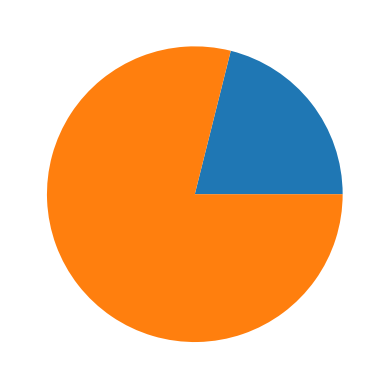

In [28]:
plt.pie(df2)

Please plot the frequency of each subscription option with a bar chart:

<Axes: xlabel='Subscription_Type', ylabel='Trip_ID'>

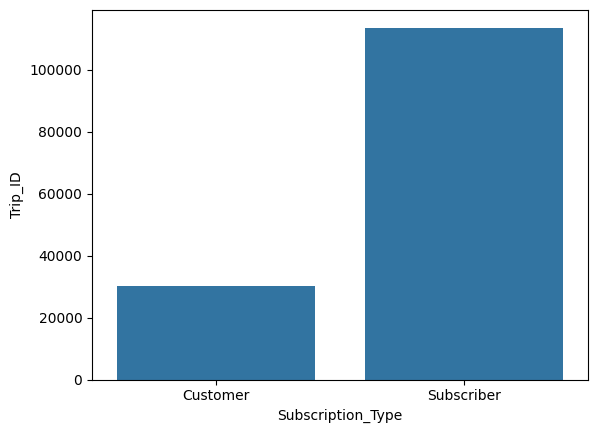

In [29]:
sns.barplot(df2)

Have a look at the start_station column: Which 10 stations occur most frequently?

In [54]:
df.groupby(by='Start_Station').agg('count')[['Trip_ID']].sort_values('Trip_ID', ascending=False)[:10]

,Trip_ID
Start_Station,
San Francisco Caltrain (Townsend at 4th),9838
Harry Bridges Plaza (Ferry Building),7343
Embarcadero at Sansome,6545
Market at Sansome,5922
Temporary Transbay Terminal (Howard at Beale),5113
Market at 4th,5030
2nd at Townsend,4987
San Francisco Caltrain 2 (330 Townsend),4976
Steuart at Market,4913


Now look at the end_station column: Which 10 stations occur the least often?

In [55]:
df.groupby(by='End_Station').agg('count')[['Trip_ID']].sort_values('Trip_ID', ascending=True)[:10]

,Trip_ID
End_Station,
Mezes Park,5
San Jose Government Center,23
Broadway at Main,56
Franklin at Maple,93
San Antonio Shopping Center,93
San Mateo County Center,106
Redwood City Public Library,117
Castro Street and El Camino Real,129
Redwood City Medical Center,178


Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [65]:
print(pd.crosstab(df['Start_Station'], df['Subscription_Type'], rownames=['Subscription_Type'], colnames=['Start_Station']))

Start_Station                                  Customer  Subscriber
Subscription_Type                                                  
2nd at Folsom                                       427        3349
2nd at South Park                                   535        3923
2nd at Townsend                                     882        4105
5th at Howard                                       606        2029
Adobe on Almaden                                     75         260
...                                                 ...         ...
Temporary Transbay Terminal (Howard at Beale)       427        4686
Townsend at 7th                                     518        3975
University and Emerson                              328         106
Washington at Kearney                               561         911
Yerba Buena Center of the Arts (3rd @ Howard)       628        1859

[69 rows x 2 columns]


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

<Axes: >

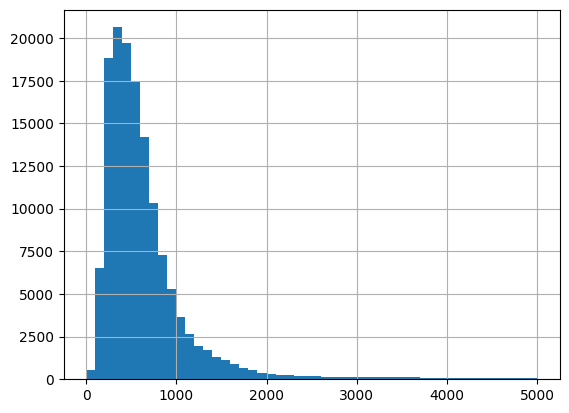

In [73]:
df['Duration'].hist(range=(0, 5000), bins=50)

<Axes: >

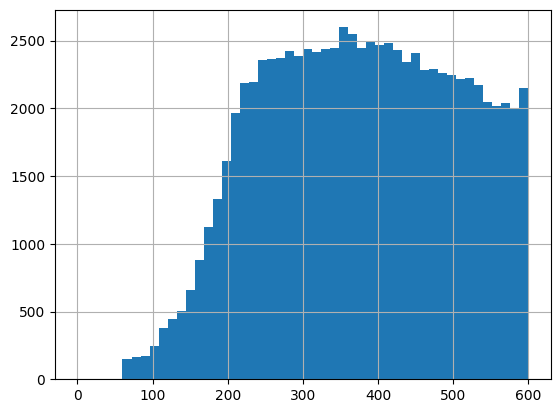

In [76]:
df['Duration'].hist(range=(0, 600), bins=50)

What do you think is going on with the short trips?

**It should be a lot of returns, because bike is not fine. It is unlikely, stations are too close to each other.** 

What is the longest trip?

In [84]:
df[df['Duration'] == df['Duration'].max()]

,Trip_ID,Duration,Start_Date,Start_Station,Start_Terminal,End_Date,End_Station,End_Terminal,Bike_num,Subscription_Type,Zip_Code
80510,111309,722236,11/30/2013 13:29,University and Emerson,35,12/8/2013 22:06,University and Emerson,35,247,Customer,94301


How would you define a "long" trip? How many trips are "long" according to your definition?

**There is distribution of trips length. One can use Full Width at Half Maximum **

In [110]:
df.count()

Trip_ID              144015
Duration             144015
Start_Date           144015
Start_Station        144015
Start_Terminal       144015
End_Date             144015
End_Station          144015
End_Terminal         144015
Bike_num             144015
Subscription_Type    144015
Zip_Code             137885
dtype: int64

In [111]:
FWHM = 500
df[df['Duration'] > df['Duration'].median()+FWHM]['Trip_ID'].count()

np.int64(21921)

Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

*One option can be, that a lot of bugs happens during the return. People actually returned it earlier, but the system didn't registered it correctly. One can analyze start and finish stations to compare geographical distance and duration of rental.*

Plot the duration column.

<Axes: xlabel='Duration', ylabel='Count'>

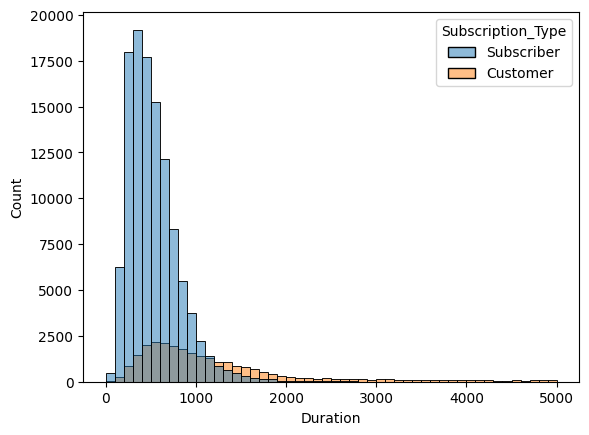

In [114]:
sns.histplot(data=df, x='Duration', hue='Subscription_Type', binrange=(0, 5000), bins=50)

Does this plot give any insights?

*In this plot it is visible, that subscriber and customer have different distributions, and more long rides happens with customer subscriptoin*

Select subsections of the data to make plots that provide more insights.

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [122]:
df[['End_Station', 'Start_Station']] = df[['End_Station', 'Start_Station']].apply(lambda col: col.str.replace(' ', '_'))

Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 

In [124]:
# How many rides where start and end terminal are the same

In [127]:
df3 = df[df['Start_Station'] == df['End_Station']]

<Axes: xlabel='Duration', ylabel='Count'>

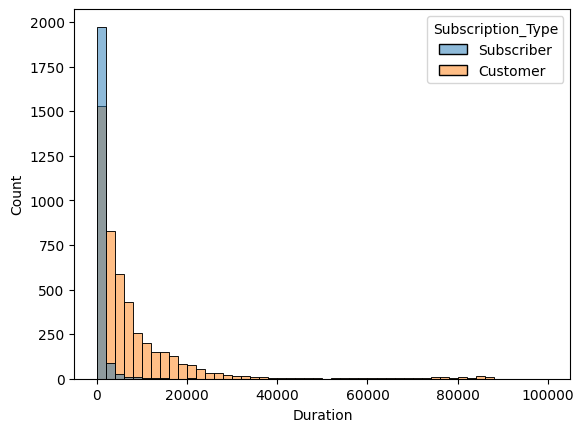

In [132]:
sns.histplot(data=df3, x='Duration', hue='Subscription_Type', binrange=(0, 10**5), bins=50)

In [134]:
# I'd like to know whether it is the same bike, that is problematic, and rides either to short or too long

In [137]:
df3['Bike_num'].count()

np.int64(6878)

In [144]:
sns.scatterplot(x = df3['Bike_num'], y = 

AttributeError: 'Series' object has no attribute 'scatter'

In [140]:
df3['Bike_num'].sort_values(ascending=False)

108412    717
116745    717
80656     717
76533     716
58046     716
         ... 
1375        9
6168        9
12277       9
2039        9
12759       9
Name: Bike_num, Length: 6878, dtype: int64

In [145]:
# Split original data into short, medium, and long distance rides

In [147]:
df['Distance_Category'] = pd.cut(
    df['Duration'],
    bins=[0, 300, 1200, float('inf')],
    labels=['short', 'medium', 'long'],
    right=False
)

In [151]:
df.columns

Index(['Trip_ID', 'Duration', 'Start_Date', 'Start_Station', 'Start_Terminal',
       'End_Date', 'End_Station', 'End_Terminal', 'Bike_num',
       'Subscription_Type', 'Zip_Code', 'Distance_Category'],
      dtype='object')

In [152]:
df['station_type'] = df.apply(
    lambda row: 'Same Station' if row['Start_Station'] == row['End_Station'] else 'Different Station',
    axis=1
)

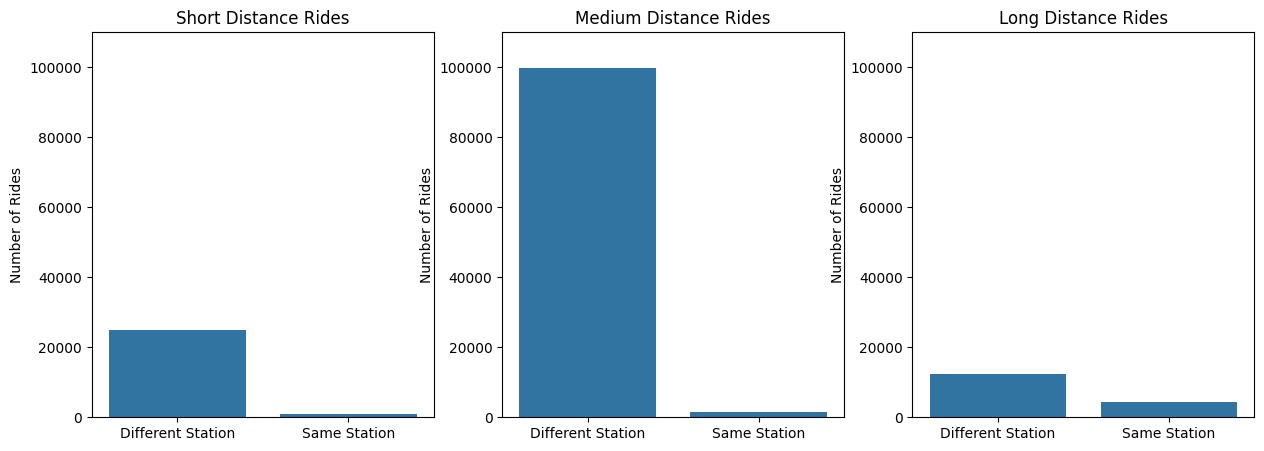

In [155]:
# Create a column to identify same vs different station rides


# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define the categories and titles
categories = ['short', 'medium', 'long']
titles = ['Short Distance Rides', 'Medium Distance Rides', 'Long Distance Rides']

# Create a barplot for each distance category
for i, (category, title) in enumerate(zip(categories, titles)):
    # Filter data for this category
    category_data = df[df['Distance_Category'] == category]
    
    # Count rides by station type
    counts = category_data['station_type'].value_counts().reset_index()
    counts.columns = ['Station Type', 'Count']
    
    # Create barplot
    sns.barplot(data=counts, x='Station Type', y='Count', ax=axes[i])
    axes[i].set_ylim(0, 110000)
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Rides')

*this is visible, that there are much more same station ride portion relative to different station, compared with short and medium rides. It means, logging that bycicle is available again on the station is not correct.*

(0.0, 1800.0)

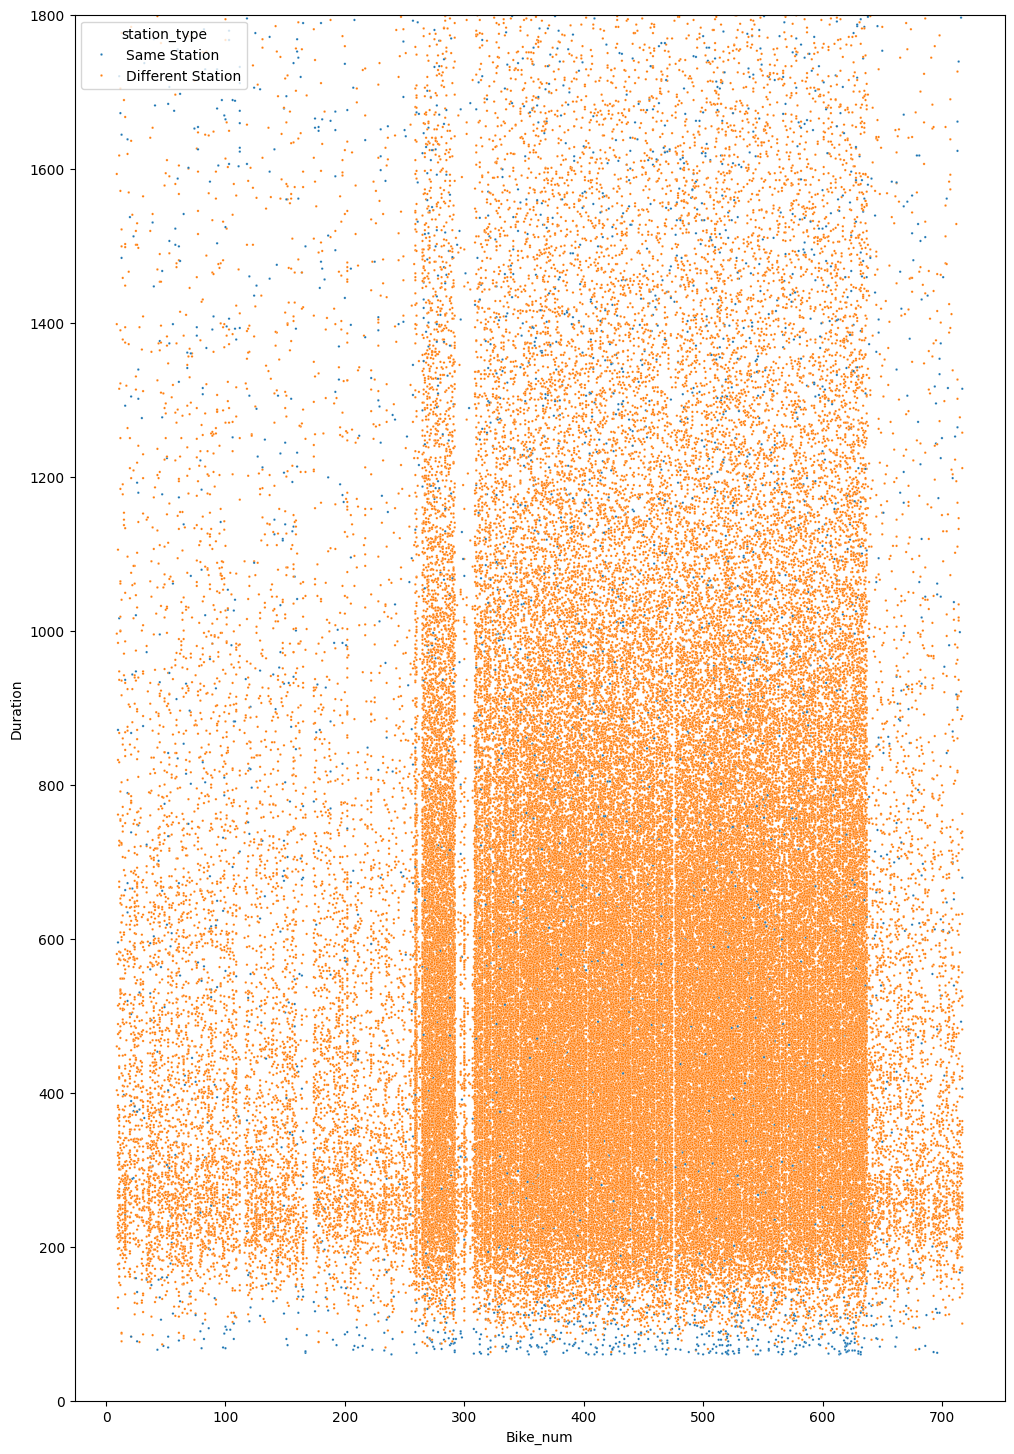

In [172]:
fig = plt.figure(figsize=(12, 18))
ax = sns.scatterplot(data=df, x='Bike_num', y='Duration', hue='station_type', s=3)
# ax.set_xlim(300, 1200)  # For x-axis limits
# OR
ax.set_ylim(0, 1800)  # For y-axis limits

In [173]:
# One can explore more accurately, using ride index, that it was the same station or not the same. 